# Week 5: LSTM on Sequential Digits (scikit-learn)

**Task:** classify 8x8 handwritten digit images into 10 classes.
**Why it is a sequence problem:** each image is read row by row, so it becomes a sequence of 8 time steps with 8 features per step. An LSTM reads the rows in order and its final hidden state is passed to a linear layer that predicts the digit.
**Baseline:** 10% (random guess). **Target:** 93% test accuracy.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Data and shapes

Images: (1797, 8, 8) -> (samples, 8 steps, 8 features)
Labels: (1797,)
Class counts: [178 182 177 183 181 182 181 179 174 180]


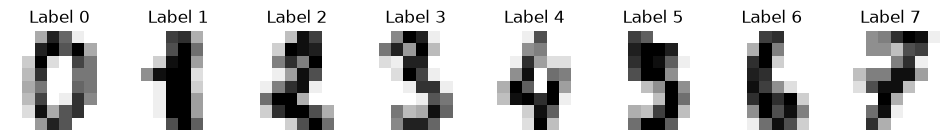

In [14]:
d = load_digits()
X = (d.images / 16.0).astype("float32")   # pixel values are 0 to 16, scale to 0 to 1
y = d.target.astype("int64")

print("Images:", X.shape, "-> (samples, 8 steps, 8 features)")
print("Labels:", y.shape)
print("Class counts:", np.bincount(y))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, lab in zip(axes, d.images, d.target):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(f"Label {lab}")
    ax.axis("off")
plt.show()

In [15]:
# Fixed 80/20 train/test split. A validation set is carved out of the training part only.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.10, random_state=SEED, stratify=y_trainval)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

def make_loader(Xa, ya, shuffle):
    ds = TensorDataset(torch.from_numpy(Xa), torch.from_numpy(ya))
    return DataLoader(ds, batch_size=64, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, True)
val_loader   = make_loader(X_val, y_val, False)
test_loader  = make_loader(X_test, y_test, False)

Train: (1293, 8, 8) Val: (144, 8, 8) Test: (360, 8, 8)


## 2. Model definition

In [16]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=8, hidden_size=128, num_classes=10):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)   # h_n: (1, batch, hidden), last hidden state
        return self.fc(h_n[-1])

model = LSTMClassifier().to(device)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

LSTMClassifier(
  (lstm): LSTM(8, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)
Trainable parameters: 71946


## 3. Training

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
EPOCHS = 40

def evaluate(loader):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            total_loss += criterion(out, yb).item() * len(yb)
            correct += (out.argmax(1) == yb).sum().item()
            n += len(yb)
    return total_loss / n, correct / n

history = {"train_loss": [], "val_loss": [], "val_acc": []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    running, n = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(yb)
        n += len(yb)
    val_loss, val_acc = evaluate(val_loader)
    history["train_loss"].append(running / n)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | train loss {running/n:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.4f}")

Epoch  1 | train loss 2.1835 | val loss 1.9138 | val acc 0.2708
Epoch  5 | train loss 0.5263 | val loss 0.5089 | val acc 0.8472
Epoch 10 | train loss 0.2465 | val loss 0.2614 | val acc 0.9236
Epoch 15 | train loss 0.1413 | val loss 0.1814 | val acc 0.9583
Epoch 20 | train loss 0.0441 | val loss 0.1884 | val acc 0.9444
Epoch 25 | train loss 0.0464 | val loss 0.1607 | val acc 0.9583
Epoch 30 | train loss 0.0368 | val loss 0.1605 | val acc 0.9514
Epoch 35 | train loss 0.0054 | val loss 0.1430 | val acc 0.9583
Epoch 40 | train loss 0.0137 | val loss 0.2804 | val acc 0.9167


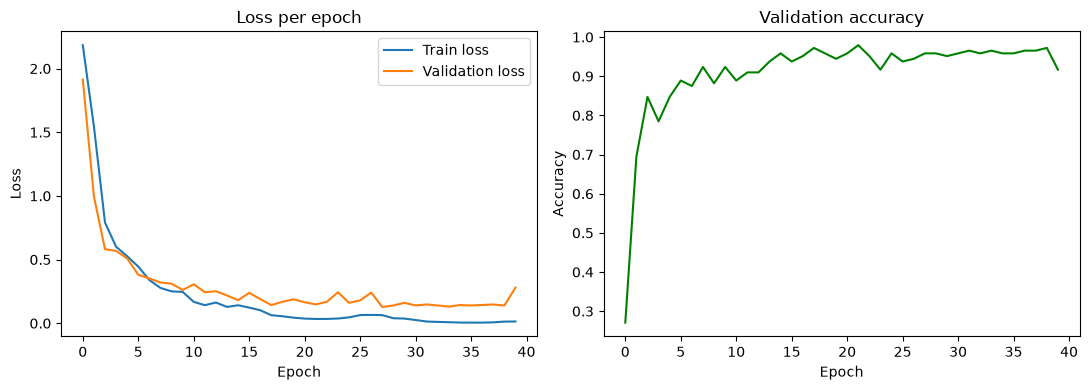

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="Train loss")
ax[0].plot(history["val_loss"], label="Validation loss")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].set_title("Loss per epoch"); ax[0].legend()
ax[1].plot(history["val_acc"], color="green")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].set_title("Validation accuracy")
plt.tight_layout()
plt.show()

## 4. Test results

Test accuracy: 95.56%


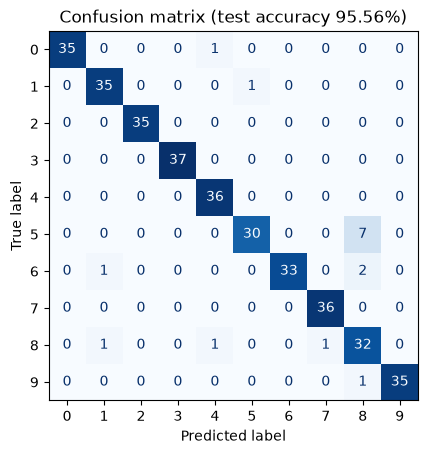

Test accuracy 95.56% vs baseline 10% and target 93%: target met


In [19]:
test_loss, test_acc = evaluate(test_loader)
print(f"Test accuracy: {test_acc*100:.2f}%")

model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
preds = np.concatenate(preds)

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(cmap="Blues", colorbar=False)
plt.title(f"Confusion matrix (test accuracy {test_acc*100:.2f}%)")
plt.show()

baseline, target = 0.10, 0.93
print(f"Test accuracy {test_acc*100:.2f}% vs baseline {baseline*100:.0f}% and target {target*100:.0f}%:",
      "target met" if test_acc >= target else "below target")